# 30 — Mini EDA Project

## Goal
To complete a small exploratory data analysis workflow and prepare for modeling.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "raw" / "motionsense_raw.csv"
CLEAN_PATH = DATA_DIR / "processed" / "motionsense_clean.csv"
ML_READY_PATH = DATA_DIR / "processed" / "motionsense_ml_ready.csv"
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Mini EDA workflow

1. Load clean data
2. Check class balance
3. Summarize numeric features
4. Compare activities
5. Create visualizations
6. Save a chart for reporting

In [2]:
# Step 1: Load clean data.
df = pd.read_csv(CLEAN_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1320, 13)


,row_id,subject,time_step,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,device,acc_magnitude,gyro_magnitude
0,1,3,0,Walking,-0.190664,0.687583,1.129328,0.005386,-0.143240,0.014062,phone_A,1.335853,0.144029
1,2,24,1,Walking,0.010593,0.542629,0.998704,0.316734,0.085557,0.007263,phone_B,1.136647,0.328166
2,3,13,2,Walking,0.221782,0.375365,1.277480,0.114523,0.096630,-0.005492,phone_A,1.349830,0.149943
3,4,25,3,Walking,0.167558,0.386942,1.495453,0.203002,-0.047116,-0.038735,phone_A,1.553763,0.211967
4,5,11,4,Walking,0.330682,0.558338,1.472442,0.455581,-0.044706,-0.056347,phone_A,1.609092,0.461224


In [3]:
# Step 2: Check activity counts.
activity_counts = df["activity"].value_counts()
activity_counts

activity
Walking               220
Walking Upstairs      220
Walking Downstairs    220
Sitting               220
Standing              220
Laying                220
Name: count, dtype: int64

In [4]:
# Step 3: Summarize important motion features.
features = ["acc_magnitude", "gyro_magnitude"]
df[features].describe().round(3)

,acc_magnitude,gyro_magnitude
count,1320.000,1320.000
mean,1.024,0.169
std,0.476,0.152
min,0.181,0.004
25%,0.826,0.036
50%,1.005,0.075
75%,1.298,0.295
max,2.632,0.617


In [5]:
# Step 4: Compare average movement by activity.
summary = (
    df.groupby("activity")
    .agg(
        observations=("activity", "count"),
        average_acc=("acc_magnitude", "mean"),
        average_gyro=("gyro_magnitude", "mean")
    )
    .round(3)
    .sort_values(by="average_acc", ascending=False)
)

summary

,observations,average_acc,average_gyro
activity,,,
Walking Upstairs,220,1.397,0.325
Walking Downstairs,220,1.308,0.295
Walking,220,1.184,0.280
Standing,220,1.003,0.040
Sitting,220,0.997,0.045
Laying,220,0.253,0.031


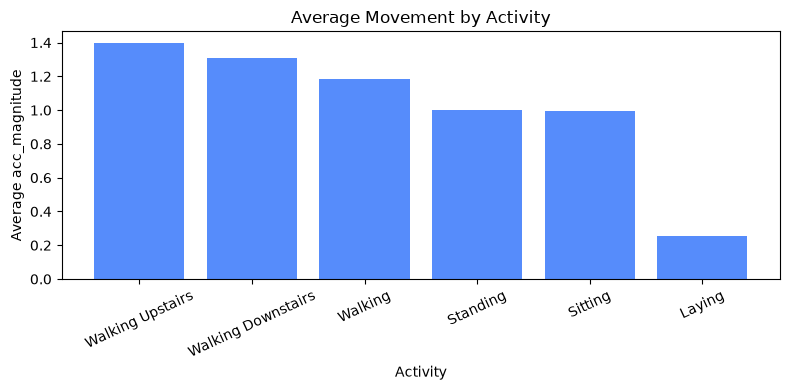

In [6]:
# Step 5: Create a final bar chart.
plt.figure(figsize=(8, 4))
plt.bar(summary.index, summary["average_acc"])
plt.title("Average Movement by Activity")
plt.xlabel("Activity")
plt.ylabel("Average acc_magnitude")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

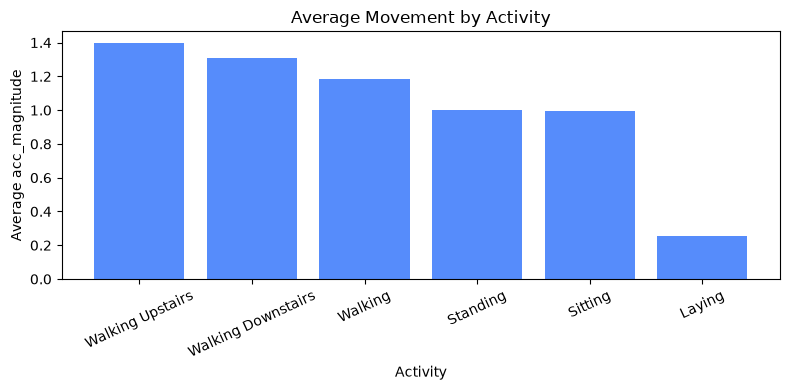

Saved figure to: figures/average_movement_by_activity.png


In [7]:
# Step 6: Save the chart for a report or presentation.
figure_path = FIGURE_DIR / "average_movement_by_activity.png"

plt.figure(figsize=(8, 4))
plt.bar(summary.index, summary["average_acc"])
plt.title("Average Movement by Activity")
plt.xlabel("Activity")
plt.ylabel("Average acc_magnitude")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure to:", figure_path)

## Research-style conclusion
Based on the summary table and chart, we can compare activities by their average movement. This prepares us for the next part of the project, where a machine learning model will learn these patterns automatically.